In [1]:
from asyncio import run

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import torch
from deepsnap.dataset import GraphDataset

from src.architectures import HomoGNN
from src.config import MPL_STYLE_DIR, PLOTS_DIR, PROJECT_ROOT
from src.data import DatasetLoader, GraphBuilder, Preprocessor
from src.db import PBWarehouse
from src.inference import InferenceEngine, InferenceResults
from src.models import Features, Graph, Tweet, User
from src.scraper import TweetyScraper
from src.service import UserService

plt.style.use(MPL_STYLE_DIR / "iragca_cmr10.mplstyle")

2025-11-20 13:37:10.004 | INFO     | src.config:<module>:28 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-11-20 13:37:10.005 | INFO     | src.config:<module>:67 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-11-20 13:37:10.005 | INFO     | src.config:<module>:68 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_model():
    model_path = PROJECT_ROOT / "best_model.pth"
    # NOTE: Make sure to adjust this whenever changing model architecture
    model = HomoGNN(input_size=5, hidden_size=8, num_layers=4).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    return model


def load_data(_pb: PBWarehouse):
    dataset_loader = DatasetLoader(_pb)
    data = dataset_loader.load_dataset()
    preprocessor = Preprocessor(data=data)
    return preprocessor.preprocess()


model: HomoGNN = load_model()
pb: PBWarehouse = PBWarehouse()
scraper: TweetyScraper = TweetyScraper(previous_session=True)
user_service = UserService(pb, scraper)
data: pl.DataFrame = load_data(pb)

node_features = Features(
    tweet=[
        "favorite_count",
        # "retweet_count",
        # "bookmark_count",
        "reply_count",
        "quote_count",
        # "views",
        "source",
        "is_hateful",
    ],
    user=[
        "favourites_count",
        "follower_count",
        "following_count",
        # "number_of_tweets",
        # "listed_count",
        # "is_blue_verified",
        # "friends",
    ],
)


gb = GraphBuilder(data=data, node_features=node_features)
graph: Graph = gb.create_graph()

✅ Loading cached dataset - Done.
✅ Loading dataset - Done.
Categorizing source column...

/tmp/ipykernel_498217/1442274809.py:16: DeprecationWarning: preprocess is deprecated. Please call (__call__) the Preprocessor instance after instantiation instead.
  return preprocessor.preprocess()


✅ Categorizing source column - Done.
✅ Preprocessing data - Done.


In [86]:
gb.node_features

Features(tweet=['favorite_count', 'reply_count', 'quote_count', 'source', 'is_hateful'], user=['favourites_count', 'follower_count', 'following_count'])

In [3]:
model

HomoGNN(
  (conv1): SAGEConv(5, 8, aggr=mean)
  (output_layer): SAGEConv(8, 8, aggr=mean)
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (loss_fn): BCEWithLogitsLoss()
  (convs): ModuleList(
    (0-3): 4 x SAGEConv(8, 8, aggr=mean)
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [4]:
user = User(
    user_id = "123456789",
    username = "example_user",
    name = "Example Name",
    follower_count = 0,
    following_count = 0,
    favourites_count = 0,
    listed_count = 0,
    number_of_tweets= 0,
    description="This is an example user.",
    creation_date="2020-01-01T00:00:00Z",
)
user_vector = gb.get_features(user.model_dump(), "user")
user_vector

graph.add_node(
    int(user.user_id),
    node_label=3,
    node_feature=user_vector,
    node_type="user",
)

dataset = GraphDataset(
    [graph], task="link_pred", edge_train_mode="disjoint"
)


In [5]:
model.eval()
with torch.no_grad():
    node_embeddings, edge_label_index = model(dataset[0].to(DEVICE))
    results = InferenceResults(
        graph=graph,
        node_embeddings=node_embeddings.cpu(),
        edge_label_index=edge_label_index.cpu(),
    )

results

In [6]:
results.node_embeddings

tensor([[ 1.3898e-02,  7.0518e-04, -5.6571e-02,  ..., -6.6785e-02,
          8.8984e-03, -2.0210e-02],
        [-1.2974e-01, -3.5295e-01,  1.6016e-01,  ...,  2.2737e-02,
         -6.7158e-02,  1.5640e-01],
        [ 8.5664e-01,  7.1300e+00, -8.1376e+00,  ..., -6.5959e+00,
          2.3989e+00, -9.4433e+00],
        ...,
        [-6.6166e-01, -2.1190e+00,  6.6931e-01,  ...,  3.9268e+00,
         -2.0265e+00,  1.6464e+00],
        [-1.8981e-01,  1.0793e+00, -1.0724e+00,  ...,  2.5794e+00,
         -1.7684e+00, -1.0297e+00],
        [-1.2302e-01, -1.0290e+00,  5.7490e-01,  ...,  4.5488e-01,
         -2.2931e-01,  7.4904e-01]])

In [7]:
user_index = results.get_node_index_using_node(int(user.user_id))
user_index

61682

In [8]:
extremist_tweets_index = results.get_index_of_nodes_with_label(0)
extremist_tweets_index

[1332,
 2305,
 4034,
 6518,
 7009,
 9794,
 11557,
 12726,
 13191,
 15211,
 17082,
 20517,
 21473,
 22025,
 22447,
 23197,
 23371,
 25786,
 29908,
 31358,
 31591,
 32393,
 35053,
 35509,
 36467,
 36968,
 37767,
 38191,
 38577,
 40945,
 41836,
 42767,
 42960,
 44011,
 44105,
 44744,
 44887,
 45594,
 46437,
 46821,
 47301,
 47564,
 48099,
 50036,
 54074,
 54075,
 55483,
 55656,
 56725,
 58812,
 60479,
 60798,
 61460,
 61642]

In [9]:
results.node_embeddings[user_index]

tensor([-0.1230, -1.0290,  0.5749,  0.2319,  0.2231,  0.4549, -0.2293,  0.7490])

In [10]:
candidate_embeddings = results.node_embeddings[
    extremist_tweets_index
]  # (num_candidates, dim)
user_embedding = results.node_embeddings[user_index]  # (dim,)

# Compute dot product similarity and convert to probability
logits = torch.matmul(candidate_embeddings, user_embedding)  # (num_candidates,)
probs = torch.sigmoid(logits)  # (num_candidates,)

In [11]:
probs.sort(descending=True)

torch.return_types.sort(
values=tensor([1.0000e+00, 9.9993e-01, 9.9665e-01, 9.7125e-01, 8.1343e-01, 7.3144e-01,
        7.3030e-01, 7.2476e-01, 7.2474e-01, 7.2375e-01, 7.1718e-01, 7.0387e-01,
        5.6519e-01, 5.4850e-01, 4.8471e-01, 4.7471e-01, 3.8994e-01, 2.9183e-01,
        2.1486e-01, 2.1485e-01, 1.9692e-01, 1.4998e-01, 2.6674e-02, 2.4814e-02,
        2.2208e-02, 1.6515e-02, 7.0761e-03, 6.6022e-03, 4.3492e-03, 1.8225e-03,
        1.3280e-03, 1.2163e-03, 1.0454e-03, 6.7375e-04, 6.3516e-04, 1.8260e-04,
        1.4138e-04, 5.6732e-05, 3.6832e-05, 8.9881e-06, 3.4371e-07, 3.2531e-07,
        5.6677e-08, 3.5190e-08, 3.8515e-09, 1.1420e-10, 1.3513e-11, 6.4625e-15,
        3.1498e-17, 5.4506e-25, 1.1980e-25, 3.1468e-30, 2.0281e-37, 0.0000e+00]),
indices=tensor([48, 40, 35, 37, 10,  6, 23, 29, 49, 15, 20, 34, 45, 24, 27,  1, 17,  8,
         7, 21, 51, 39, 16, 31, 18, 14, 46,  5, 43, 50, 44,  2, 28, 26, 38, 25,
        36, 33, 42, 12, 13, 32, 30, 11, 47,  4, 41, 19, 53, 52,  3,  9, 22,  0

In [12]:
extremist_tweets_index[0]

1332

In [13]:
extremist_tweets_index[48]

56725

In [14]:
results.node_list[1332]

(1280052547831468032,
 {'node_label': 0,
  'node_feature': tensor([0., 0., 0., 0., 0.]),
  'node_type': 'tweet'})

In [15]:
Tweet(**pb.get_tweet_by_id(1280052547831468032).__dict__)

Tweet(tweet_id='1280052547831468032', text='@lausanhk @b9AcE @rhaphiikii Imperialist tools join racist, anti-communist war drive on China. There is no "3rd camp" only those who are shamefaced in their treachery against the interests of the workers of the world. US out of HK &amp; the South China Sea! Smash US backed blackshirts in HK!', status_link='https://x.com/Gohahwei1/status/1280052547831468032', user_id='1158919762040066048', is_extremist=False, is_annotated=False, in_reply_to_status_link='https://x.com/lausanhk/status/1278387912149807108', in_reply_to_status_id='1278387912149807108', bookmark_count=0, views=0, retweet_count=0, favorite_count=0, reply_count=0, quote_count=0, conversation_id='1278375675683053570', retweet_status_id='', quoted_status_id='', community_note='', language='en', source='', creation_date='2020-07-06 08:14:44.000Z', has_blm_hashtag=False, fetched_replies=False, is_reply_to_blm=True, is_hateful='0')

In [16]:
results.node_list[56725]

(1272551867004805120,
 {'node_label': 0,
  'node_feature': tensor([1., 1., 0., 0., 0.]),
  'node_type': 'tweet'})

In [17]:
Tweet(**pb.get_tweet_by_id(1272551867004805120).__dict__).text

'Sad fact. Police shoot and kill blacks more often than any other race in this nation. #mondaythoughts #MondayMorning #MondayVibes #MondayMood #mondaytruth #PoliceBrutalityPandemic #PoliceReformNow #BLACK_LIVES_MATTER #blm #JusticeForGeorgeFloyd #JusticeForRayshardBrooks https://t.co/w87OQZorZ7'

In [18]:
user_embedding @ results.node_embeddings[1332]

tensor(-315.5820)

In [19]:
torch.sigmoid(user_embedding @ results.node_embeddings[1332])

tensor(0.)

In [83]:
user_embedding @ results.node_embeddings[56725]

tensor(93.8712)

In [84]:
torch.sigmoid(user_embedding @ results.node_embeddings[56725])

tensor(1.)

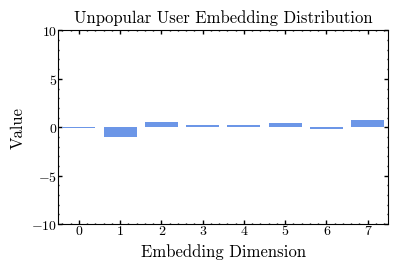

In [21]:
sns.barplot(user_embedding.numpy())
plt.ylim(-10, 10)

plt.title("Unpopular User Embedding Distribution")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "unpopular_user_embedding_distribution.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [22]:
results.node_embeddings[1332]

tensor([ -21.2409,  150.9102, -136.3871,   21.2023,    4.7030,  -76.1640,
           0.3143,  -74.4282])

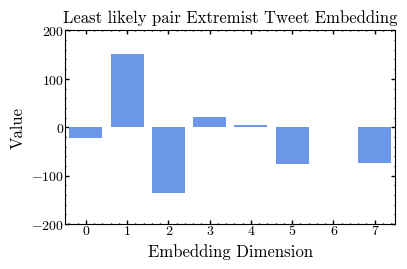

In [23]:
sns.barplot(results.node_embeddings[1332].numpy())
plt.ylim(-200, 200)
plt.title("Least likely pair Extremist Tweet Embedding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "[unpopular_user] least_likely_extremist_tweet_embedding.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [24]:
results.node_embeddings[56725]

tensor([  1.7560, -18.1422,  21.0492, -38.0049,  34.5069,  82.3447, -49.6473,
         20.8149])

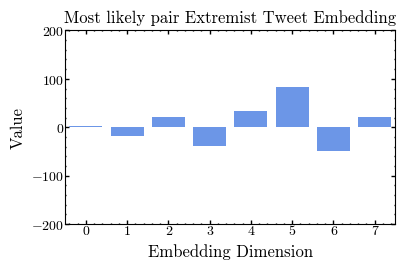

In [25]:
sns.barplot(results.node_embeddings[56725].numpy())
plt.ylim(-200, 200)
plt.title("Most likely pair Extremist Tweet Embedding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "[unpopular_user] most_likely_extremist_tweet_embedding.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [26]:
torch.sigmoid(user_embedding @ results.node_embeddings[38191])

tensor(0.4847)

In [27]:
torch.sigmoid(user_embedding @ results.node_embeddings[1332])

tensor(0.)

# Popular user

In [28]:
user2 = User(
    user_id = "123456780",
    username = "popular_user",
    name = "Example Popular User Name",
    follower_count = 100000,
    following_count = 10000,
    favourites_count = 10000,
    listed_count = 100000,
    number_of_tweets= 10000,
    friends=5000,
    description="This is an example popular user.",
    creation_date="2020-02-01T00:00:00Z",
)
user_vector2 = gb.get_features(user2.model_dump(), "user")
user_vector2

graph.add_node(
    int(user2.user_id),
    node_label=3,
    node_feature=user_vector2,
    node_type="user",
)

dataset = GraphDataset(
    [graph], task="link_pred", edge_train_mode="disjoint"
)


In [29]:
model.eval()
with torch.no_grad():
    node_embeddings, edge_label_index = model(dataset[0].to(DEVICE))
    results2 = InferenceResults(
        graph=graph,
        node_embeddings=node_embeddings.cpu(),
        edge_label_index=edge_label_index.cpu(),
    )

results2

In [30]:
user2_index = results2.get_node_index_using_node(int(user2.user_id))
user2_index

61683

In [31]:
user2_embedding = results2.node_embeddings[user2_index]
user2_embedding

tensor([-0.3170,  1.0503, -2.0631,  5.7204, -3.4529,  0.4413, -0.9158,  1.3543])

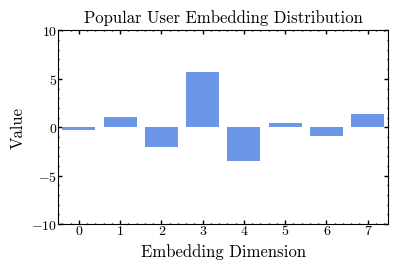

In [32]:
sns.barplot(user2_embedding.numpy())
plt.ylim(-10, 10)
plt.title("Popular User Embedding Distribution")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "popular_user_embedding_distribution.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [33]:
candidate_embeddings = results.node_embeddings[
    extremist_tweets_index
]  # (num_candidates, dim)
user2_embedding = results2.node_embeddings[user2_index]  # (dim,)

# Compute dot product similarity and convert to probability
logits = torch.matmul(candidate_embeddings, user2_embedding)  # (num_candidates,)
probs = torch.sigmoid(logits)  # (num_candidates,)
probs.sort(descending=True)

torch.return_types.sort(
values=tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 9.9999e-01, 9.9999e-01, 9.9998e-01, 9.9995e-01, 9.9992e-01,
        9.9986e-01, 9.9980e-01, 9.9970e-01, 9.9969e-01, 9.9951e-01, 9.9923e-01,
        9.9823e-01, 9.9707e-01, 9.9316e-01, 9.8998e-01, 9.6447e-01, 7.3156e-01,
        7.3149e-01, 6.4324e-01, 6.1590e-01, 5.5681e-01, 5.0249e-01, 3.8128e-01,
        1.2022e-01, 8.3417e-02, 8.2130e-02, 8.2130e-02, 7.8425e-02, 7.0430e-02,
        5.9528e-02, 5.9322e-02, 5.5112e-02, 4.7987e-02, 1.3575e-02, 1.2793e-02,
        1.3013e-03, 1.8167e-06, 3.3855e-19, 8.4129e-20, 0.0000e+00, 0.0000e+00]),
indices=tensor([ 0, 22, 41, 19, 47, 30, 12,  9, 32, 37,  4,  3, 11, 38, 25, 28, 44, 26,
         2, 50, 13, 43,  5, 36, 46, 14, 18, 16, 31, 21,  7, 51, 39, 27,  8,  1,
        24, 15, 49, 29,  6, 20, 34, 23, 17, 45, 10, 35, 33, 42, 52, 40, 48, 53

In [34]:
extremist_tweets_index[0]

1332

In [35]:
extremist_tweets_index[53]

61642

In [85]:
results.node_list[61642]

(1274306154823368706,
 {'node_label': 0,
  'node_feature': tensor([2473.,  259.,   56.,    0.,    0.]),
  'node_type': 'tweet'})

In [74]:
user2_embedding @ results2.node_embeddings[1332]

tensor(416.9562)

In [75]:
torch.sigmoid(user2_embedding @ results2.node_embeddings[1332])

tensor(1.)

In [78]:
user2_embedding @ results2.node_embeddings[61642]

tensor(-96.9587)

In [76]:
torch.sigmoid(user2_embedding @ results2.node_embeddings[61642])

tensor(0.)

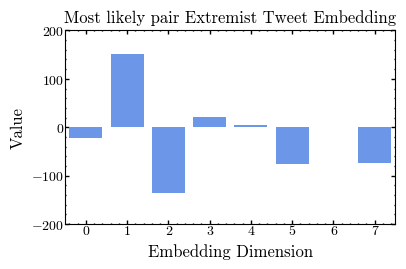

In [36]:
sns.barplot(results.node_embeddings[1332].numpy())
plt.ylim(-200, 200)

plt.title("Most likely pair Extremist Tweet Embedding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "[popular_user] most_likely_extremist_tweet_embedding.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

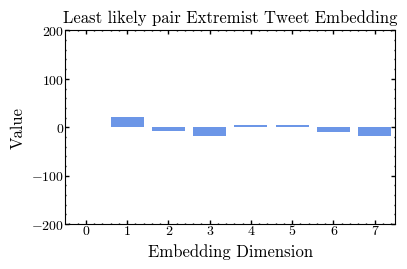

In [37]:
sns.barplot(results.node_embeddings[61642].numpy())
plt.ylim(-200, 200)
plt.title("Least likely pair Extremist Tweet Embedding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "[popular_user] least_likely_extremist_tweet_embedding.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [38]:
results2.node_embeddings[53]

tensor([ 0.1526, -2.0399,  0.7787,  0.8235,  1.0158,  1.7415, -0.3051,  0.9444])

## Rough relationship estimation

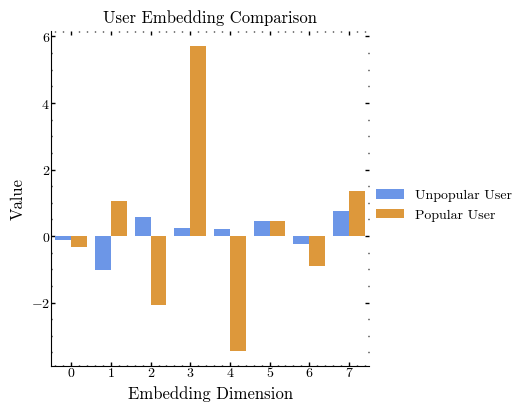

In [72]:

data = {
    "user": ["Unpopular User"] * 8 + ["Popular User"] * 8,
    "dimension": list(range(0, 8)) * 2,
    "value": user_embedding.numpy().tolist() + user2_embedding.numpy().tolist(),
}

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=data,
    kind="bar",
    x="dimension",
    y="value",
    hue="user",
    height=4,
    # legend=False
)
g.legend.set_title("")
plt.title("User Embedding Comparison")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.savefig(PLOTS_DIR / "user_embedding_comparison.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

Text(56.1399796040853, 0.5, 'Value')

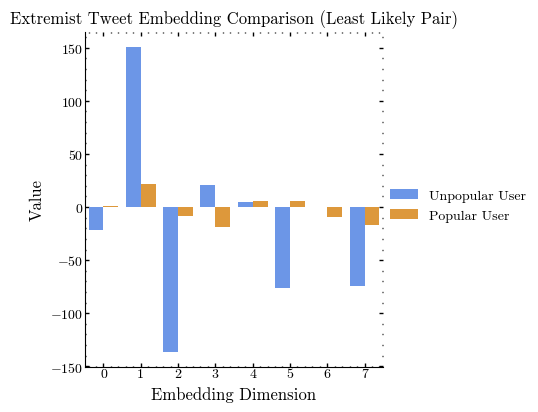

In [ ]:
data = {
    "user": ["Unpopular User"] * 8 + ["Popular User"] * 8,
    "dimension": list(range(0, 8)) * 2,
    "value": results.node_embeddings[1332].numpy().tolist() + results.node_embeddings[61642].numpy().tolist(),
}

g = sns.catplot(data=data, x="dimension", y="value", hue="user", kind="bar", height=4, legend=True)
g.legend.set_title("")
plt.title("Extremist Tweet Embedding Comparison (Least Likely Pair)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")

Text(56.1399796040853, 0.5, 'Value')

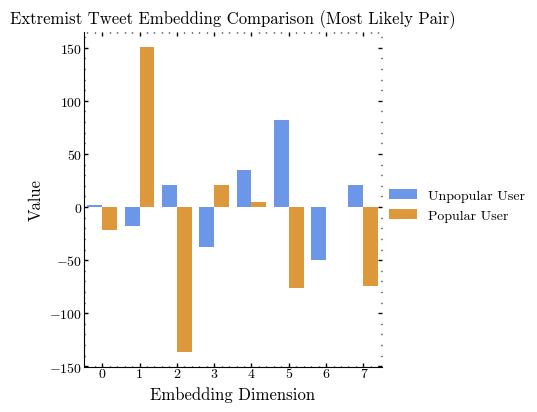

In [65]:
data = {
    "user": ["Unpopular User"] * 8 + ["Popular User"] * 8,
    "dimension": list(range(0, 8)) * 2,
    "value": results.node_embeddings[56725].numpy().tolist() + results.node_embeddings[1332].numpy().tolist(),
}

g = sns.catplot(data=data, x="dimension", y="value", hue="user", kind="bar", height=4)
g.legend.set_title("")
plt.title("Extremist Tweet Embedding Comparison (Most Likely Pair)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")

In [ ]:
pb.get_tweet_by_id(1272551867004805120)

2025-11-20 13:37:22.838 | INFO     | src.matplotlib.color:<module>:103 - Accessible color palette inspired by https://github.com/mpetroff/accessible-color-cycles.


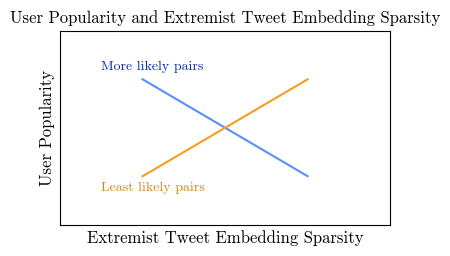

In [40]:
from src.matplotlib import Color
least_likely = [-1, 1], [1, -1]
more_likely = [-1, 1], [-1, 1]

plt.ylim(-2, 2)
plt.xlim(-2, 2)

sns.lineplot(x=least_likely[0], y=least_likely[1])
sns.lineplot(x=more_likely[0], y=more_likely[1])
plt.xlabel("Extremist Tweet Embedding Sparsity")
plt.ylabel("User Popularity")
plt.title("User Popularity and Extremist Tweet Embedding Sparsity")
plt.xticks([])
plt.yticks([])

plt.text(-1.5, 1.2, "More likely pairs", fontsize=10, color=Color.DARK_BLUE.value)
plt.text(-1.5, -1.3, "Least likely pairs", fontsize=10, color="#D08919", fontweight="bold")
plt.savefig(PLOTS_DIR / "user_popularity_vs_extremist_tweet_embedding_sparsity.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

## Edge counts

In [41]:
len(graph.edges)

36365

In [42]:
user_nodes_count = len(results.get_index_of_nodes_with_label(3))
user_nodes_count

25318

In [43]:
tweet_nodes_count = sum(len(results.get_index_of_nodes_with_label(label)) for label in [0, 1, 2])
tweet_nodes_count

36365

In [44]:
negative_edges_count = (user_nodes_count * tweet_nodes_count) - len(graph.edges)
negative_edges_count

920652705